In [ ]:
import os
import random
import wandb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

%matplotlib inline

In [ ]:
from google.colab import userdata
api = userdata.get('w&b_api') # тут нужно в ключ апишку вставить

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

class CFG:
    num_epochs = 10
    train_batch_size = 64
    test_batch_size = 256
    lr = 3e-4
    seed = 42


    wandb = True
    api = api
    project = 'skin-cancer-triage'
    entity = 'models-google5742'

def class2dict(f):
    return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

## EDA данных

In [ ]:
train_df = pd.read_csv('/content/train_metadata.csv')
test_df = pd.read_csv('/content/test_metadata.csv')
train_df = train_df.drop(columns=['img_id'])
test_df = test_df.drop(columns=['img_id'])
train_df.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_1,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,biopsed
0,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,6.0,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,True
1,PAT_1549,1882,NaN,NaN,NaN,NaN,53,NaN,NaN,NaN,...,NaN,NaN,SEK,TRUE,FALSE,FALSE,FALSE,FALSE,TRUE,False
2,PAT_117,179,False,False,POMERANIA,POMERANIA,74,True,FEMALE,False,...,15.0,10.0,BCC,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,True
3,PAT_1995,4080,NaN,NaN,NaN,NaN,68,NaN,NaN,NaN,...,NaN,NaN,ACK,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,False
4,PAT_705,4015,False,True,GERMANY,GERMANY,58,True,FEMALE,True,...,9.0,7.0,ACK,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,False


In [ ]:
train_df.shape

(1838, 25)

In [ ]:
test_df.shape

(460, 25)

In [ ]:
train_df.columns

Index(['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father',
       'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation', 'biopsed'],
      dtype='object')

In [ ]:
test_df.columns

Index(['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father',
       'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation', 'biopsed'],
      dtype='object')

In [ ]:
train_df['patient_id'].isin(test_df['patient_id']).sum()

np.int64(0)

In [ ]:
train_df['priority_level'] = train_df['diagnostic'].replace({ 'NEV': 0, 'SEK': 0, 'ACK': 1, 'BCC': 1, 'MEL': 2, 'SCC': 2})
test_df['priority_level'] = test_df['diagnostic'].replace({ 'NEV': 0, 'SEK': 0, 'ACK': 1, 'BCC': 1, 'MEL': 2, 'SCC': 2})

/tmp/ipykernel_31897/2717668203.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['priority_level'] = train_df['diagnostic'].replace({ 'NEV': 0, 'SEK': 0, 'ACK': 1, 'BCC': 1, 'MEL': 2, 'SCC': 2})
/tmp/ipykernel_31897/2717668203.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['priority_level'] = test_df['diagnostic'].replace({ 'NEV': 0, 'SEK': 0, 'ACK': 1, 'BCC': 1, 'MEL': 2, 'SCC': 2})


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1838 non-null   object 
 1   lesion_id            1838 non-null   int64  
 2   smoke                1192 non-null   object 
 3   drink                1192 non-null   object 
 4   background_father    1181 non-null   object 
 5   background_mother    1177 non-null   object 
 6   age                  1838 non-null   int64  
 7   pesticide            1192 non-null   object 
 8   gender               1192 non-null   object 
 9   skin_cancer_history  1192 non-null   object 
 10  cancer_history       1192 non-null   object 
 11  has_piped_water      1192 non-null   object 
 12  has_sewage_system    1192 non-null   object 
 13  fitspatrick          1192 non-null   float64
 14  region               1838 non-null   object 
 15  diameter_1           1192 non-null   f

In [ ]:
train_df.duplicated().sum()

np.int64(330)

In [ ]:
train_df = train_df.drop_duplicates()

In [ ]:
test_df = test_df.drop_duplicates()

In [ ]:
train_df.isna().sum()

,0
patient_id,0
lesion_id,0
smoke,572
drink,572
background_father,579
background_mother,583
age,0
pesticide,572
gender,572
skin_cancer_history,572


###Проверим зависимость пропусков

In [ ]:
clinical_missing_cols = ['smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history',
                         'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'diameter_1', 'diameter_2']

missing_block = train_df[clinical_missing_cols].isna().all(axis=1)
pd.crosstab(missing_block, train_df['diagnostic'], normalize='index')

diagnostic,ACK,BCC,MEL,NEV,SCC,SEK
row_0,,,,,,
False,0.206197,0.55235,0.028846,0.059829,0.122863,0.029915
True,0.562937,0.00000,0.000000,0.204545,0.000000,0.232517


In [ ]:
pd.crosstab(missing_block, train_df['biopsed'], margins=True)

biopsed,False,True,All
row_0,,,
False,104,832,936
True,572,0,572
All,676,832,1508


###Разобьем на 2 примера

In [ ]:
train_filled = train_df.copy()
test_filled = test_df.copy()

numeric_missing_cols = ['diameter_1', 'diameter_2']

categorical_missing_cols = [
    col for col in clinical_missing_cols
    if col not in numeric_missing_cols]

for col in numeric_missing_cols:
    train_filled[col] = train_filled[col].fillna(train_filled[col].median())
    test_filled[col] = test_filled[col].fillna(train_filled[col].median())

train_filled[categorical_missing_cols] = (train_filled[categorical_missing_cols].fillna('UNKNOWN'))
test_filled[categorical_missing_cols] = (test_filled[categorical_missing_cols].fillna('UNKNOWN'))

In [ ]:
train_df = train_df.drop(columns=clinical_missing_cols)
test_df = test_df.drop(columns=clinical_missing_cols)

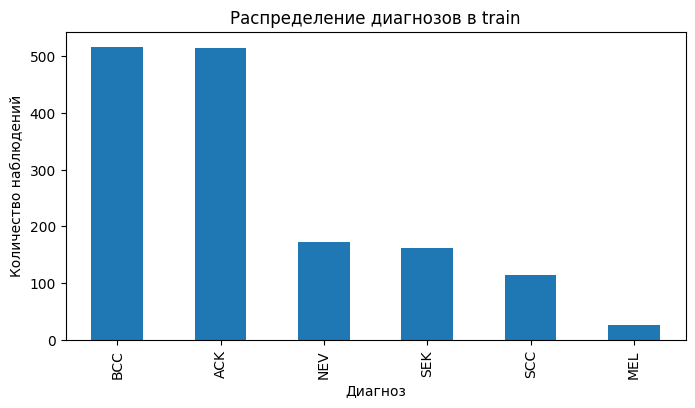

In [ ]:
train_df['diagnostic'].value_counts().plot(kind='bar', figsize=(8, 4))

plt.title('Распределение диагнозов в train')
plt.xlabel('Диагноз')
plt.ylabel('Количество наблюдений')
plt.show()

In [ ]:
priority_counts = (train_df['priority_level'].value_counts().sort_index())
priority_table = pd.DataFrame({'count': priority_counts,'percent': priority_counts / priority_counts.sum()})
priority_table

,count,percent
priority_level,,
0,334,0.221485
1,1032,0.684350
2,142,0.094164


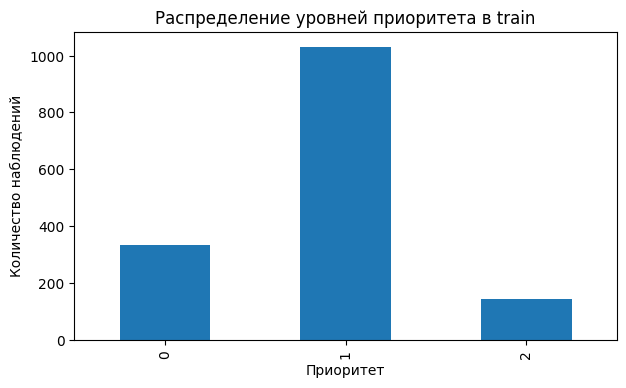

In [ ]:
priority_table['count'].plot(kind='bar', figsize=(7, 4))

plt.title('Распределение уровней приоритета в train')
plt.xlabel('Приоритет')
plt.ylabel('Количество наблюдений')
plt.show()

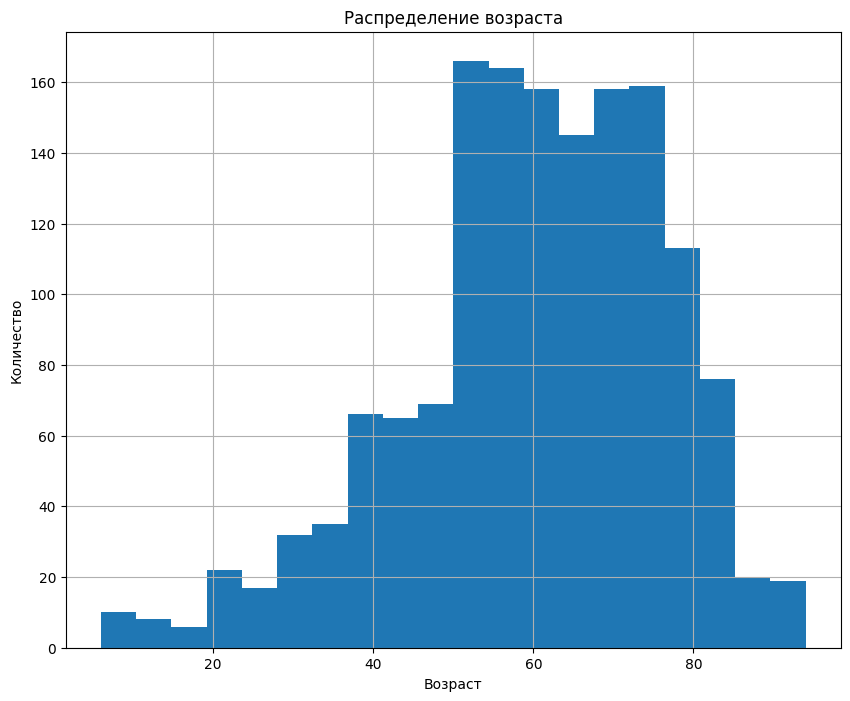

In [ ]:
plt.figure(figsize=(10, 8))
train_df['age'].hist(bins=20)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

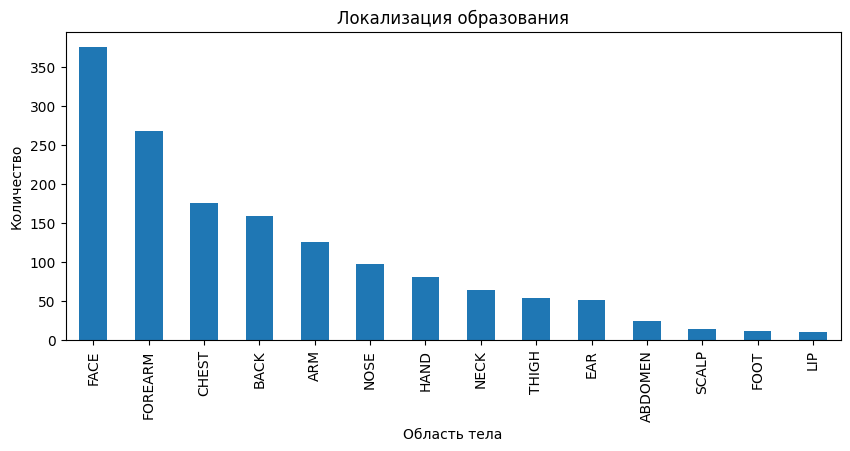

In [ ]:
plt.figure(figsize=(10, 4))
train_df['region'].value_counts().plot(kind='bar')
plt.title('Локализация образования')
plt.xlabel('Область тела')
plt.ylabel('Количество')
plt.show()

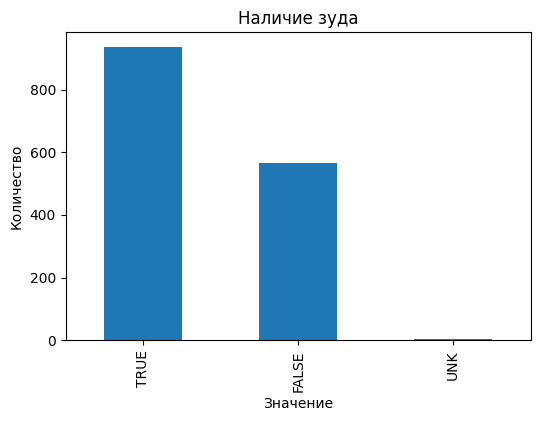

In [ ]:
plt.figure(figsize=(6, 4))
train_df['itch'].value_counts().plot(kind='bar')
plt.title('Наличие зуда')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

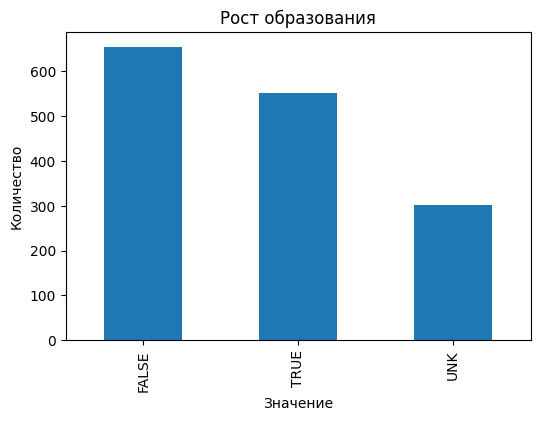

In [ ]:
plt.figure(figsize=(6, 4))
train_df['grew'].value_counts().plot(kind='bar')
plt.title('Рост образования')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

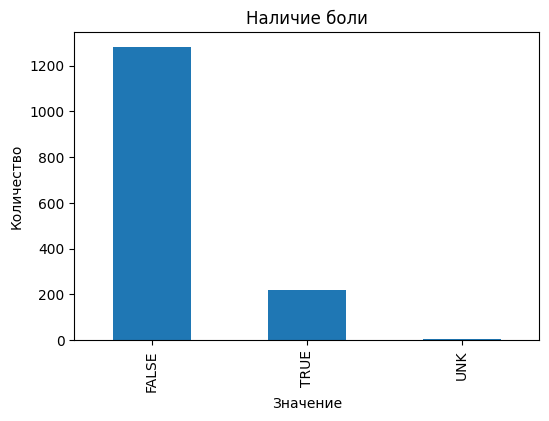

In [ ]:
plt.figure(figsize=(6, 4))
train_df['hurt'].value_counts().plot(kind='bar')
plt.title('Наличие боли')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

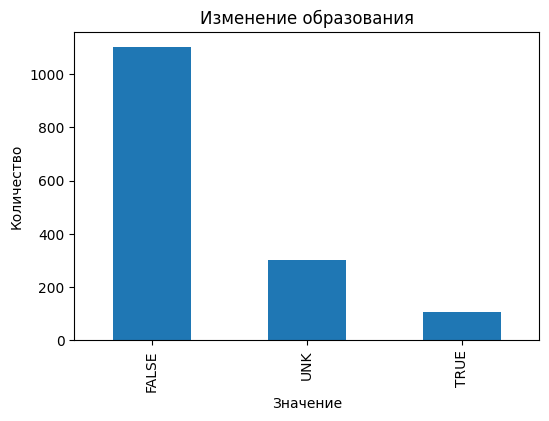

In [ ]:
plt.figure(figsize=(6, 4))
train_df['changed'].value_counts().plot(kind='bar')
plt.title('Изменение образования')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

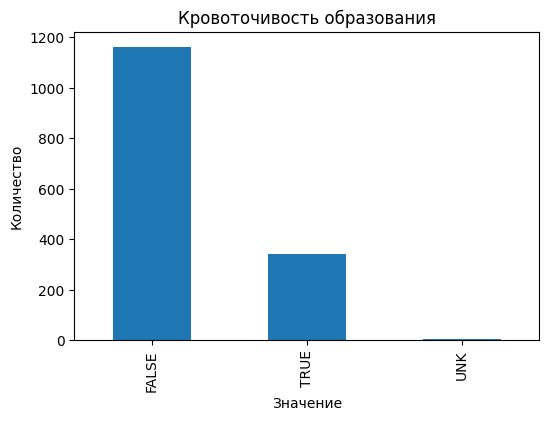

In [ ]:
plt.figure(figsize=(6, 4))
train_df['bleed'].value_counts(dropna=False).plot(kind='bar')
plt.title('Кровоточивость образования')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

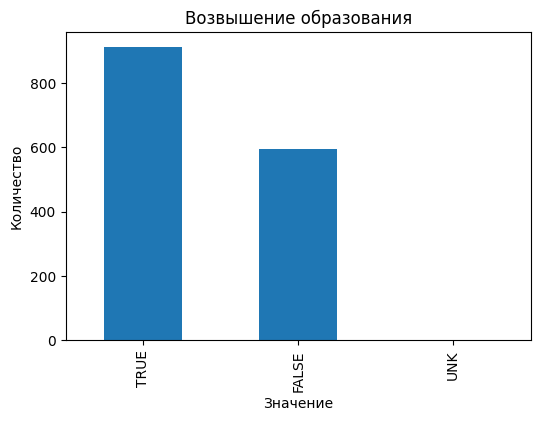

In [ ]:
plt.figure(figsize=(6, 4))
train_df['elevation'].value_counts().plot(kind='bar')
plt.title('Возвышение образования')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

теперь рассмотрим заполненные

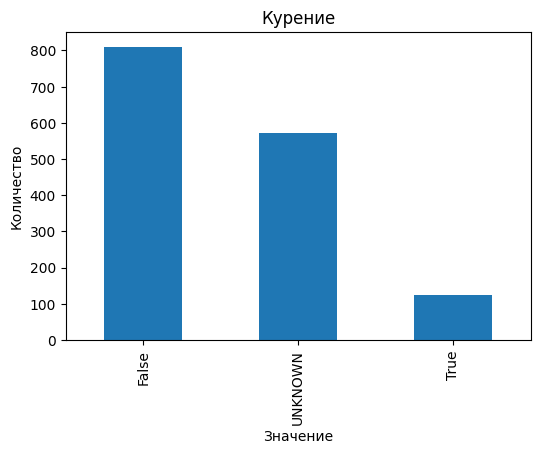

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['smoke'].value_counts().plot(kind='bar')
plt.title('Курение')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

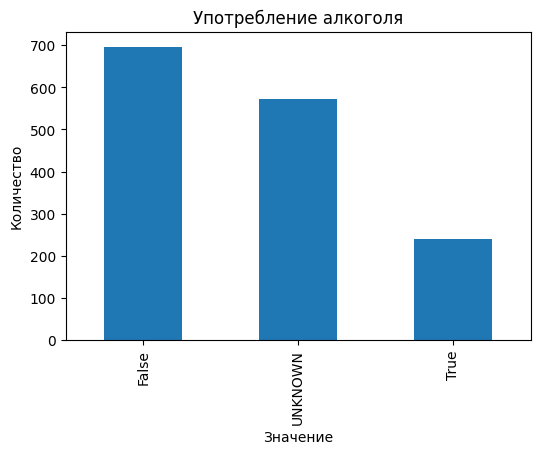

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['drink'].value_counts().plot(kind='bar')
plt.title('Употребление алкоголя')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

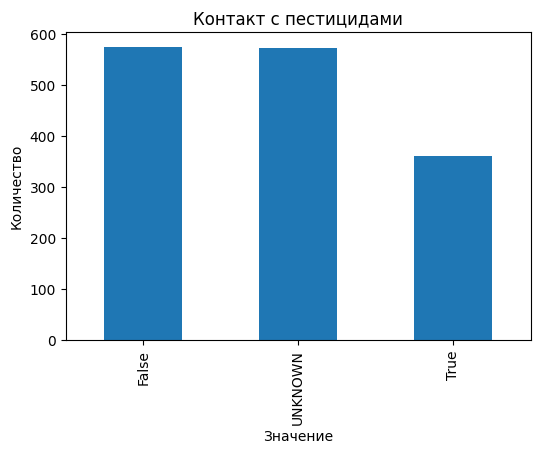

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['pesticide'].value_counts().plot(kind='bar')
plt.title('Контакт с пестицидами')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

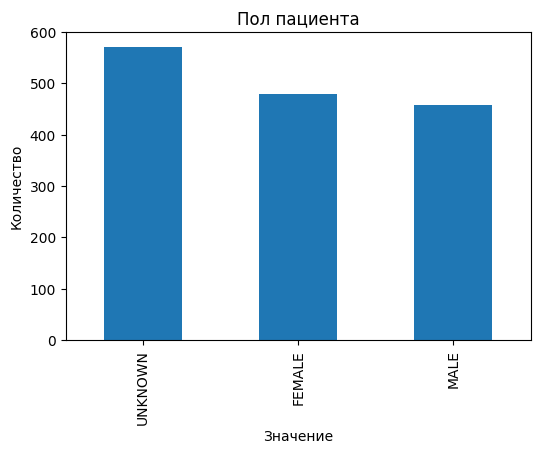

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['gender'].value_counts().plot(kind='bar')
plt.title('Пол пациента')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

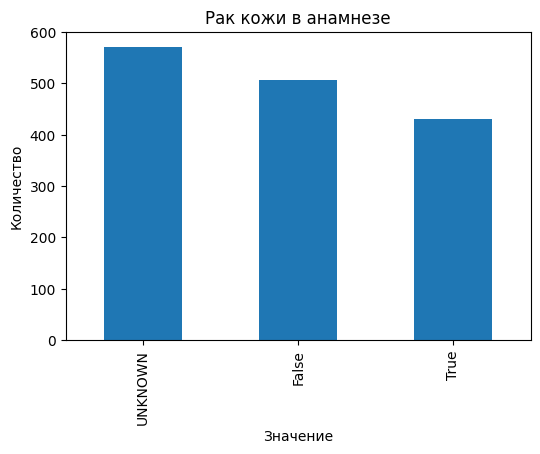

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['skin_cancer_history'].value_counts().plot(kind='bar')
plt.title('Рак кожи в анамнезе')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

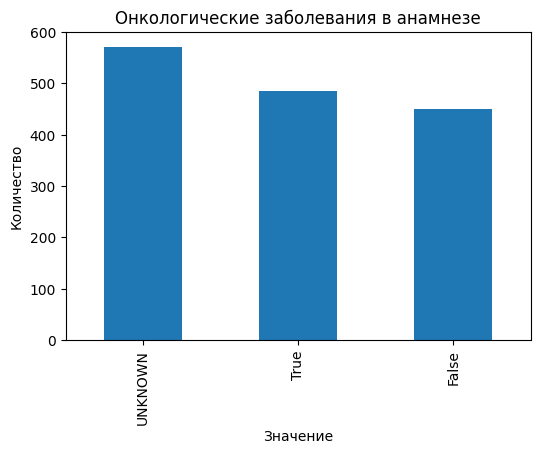

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['cancer_history'].value_counts().plot(kind='bar')
plt.title('Онкологические заболевания в анамнезе')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

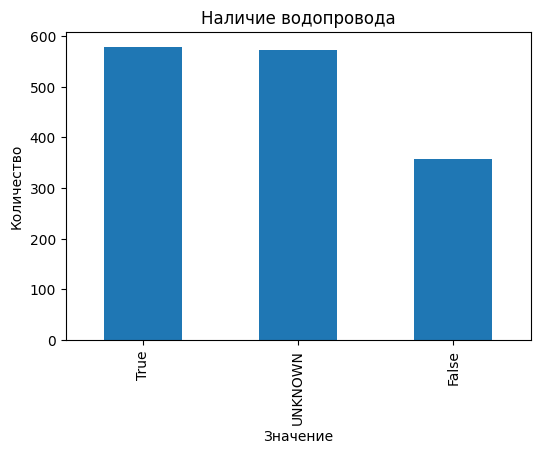

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['has_piped_water'].value_counts().plot(kind='bar')
plt.title('Наличие водопровода')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

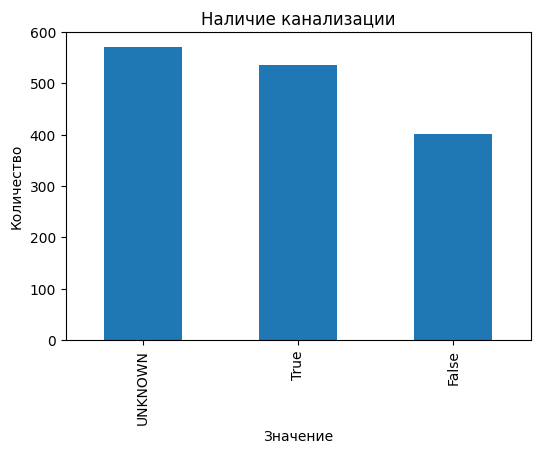

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['has_sewage_system'].value_counts().plot(kind='bar')
plt.title('Наличие канализации')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.show()

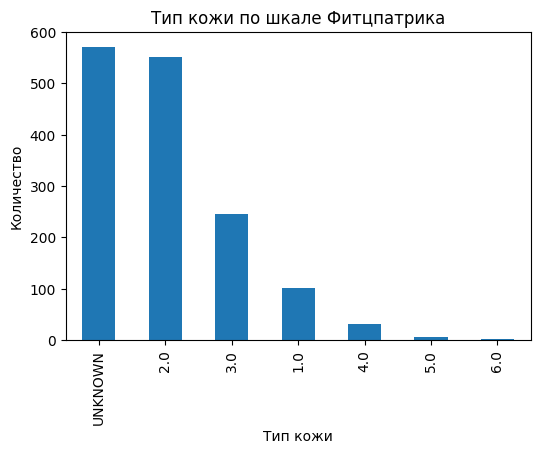

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['fitspatrick'].value_counts().plot(kind='bar')
plt.title('Тип кожи по шкале Фитцпатрика')
plt.xlabel('Тип кожи')
plt.ylabel('Количество')
plt.show()

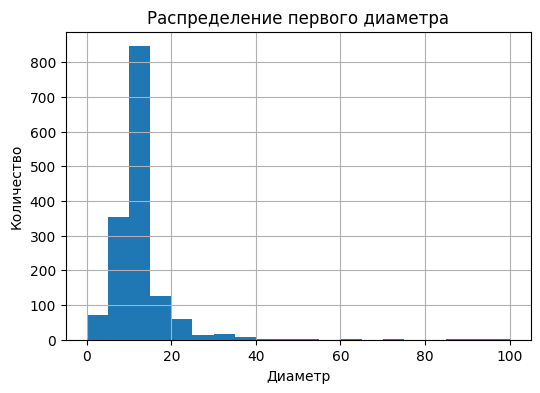

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['diameter_1'].hist(bins=20)
plt.title('Распределение первого диаметра')
plt.xlabel('Диаметр')
plt.ylabel('Количество')
plt.show()

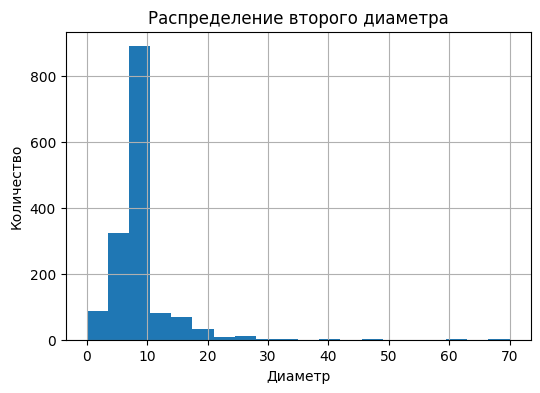

In [ ]:
plt.figure(figsize=(6, 4))
train_filled['diameter_2'].hist(bins=20)
plt.title('Распределение второго диаметра')
plt.xlabel('Диаметр')
plt.ylabel('Количество')
plt.show()

перейдем к test части

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 383 entries, 0 to 459
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      383 non-null    object
 1   lesion_id       383 non-null    int64 
 2   age             383 non-null    int64 
 3   region          383 non-null    object
 4   diagnostic      383 non-null    object
 5   itch            383 non-null    object
 6   grew            383 non-null    object
 7   hurt            383 non-null    object
 8   changed         383 non-null    object
 9   bleed           383 non-null    object
 10  elevation       383 non-null    bool  
 11  biopsed         383 non-null    bool  
 12  priority_level  383 non-null    int64 
dtypes: bool(2), int64(3), object(8)
memory usage: 36.7+ KB


In [ ]:
test_df.duplicated().sum()

np.int64(0)

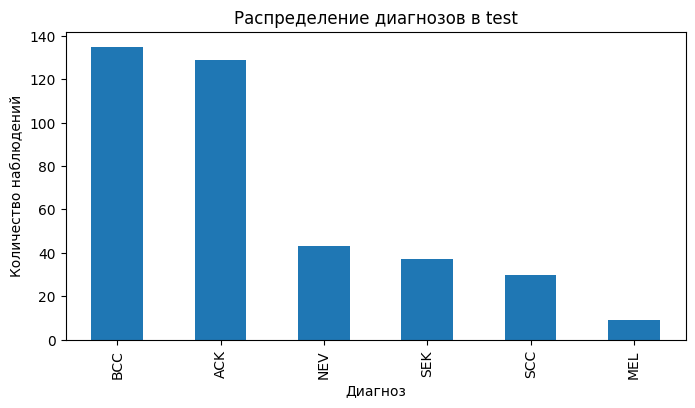

In [ ]:
test_df['diagnostic'].value_counts().plot(kind='bar', figsize=(8, 4))

plt.title('Распределение диагнозов в test')
plt.xlabel('Диагноз')
plt.ylabel('Количество наблюдений')
plt.show()

In [ ]:
priority_counts = (test_df['priority_level'].value_counts().sort_index())
priority_table = pd.DataFrame({'count': priority_counts,'percent': priority_counts / priority_counts.sum()})
priority_table

,count,percent
priority_level,,
0,80,0.208877
1,264,0.689295
2,39,0.101828


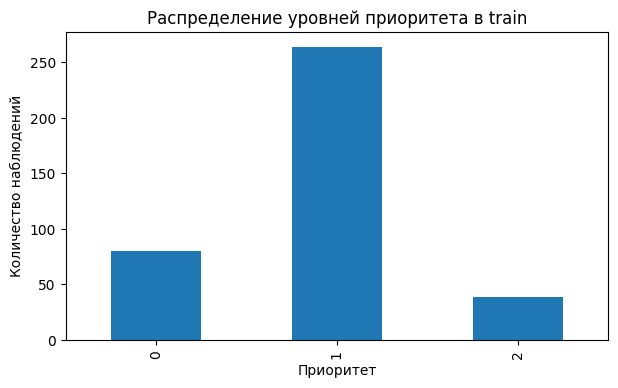

In [ ]:
priority_table['count'].plot(kind='bar', figsize=(7, 4))

plt.title('Распределение уровней приоритета в train')
plt.xlabel('Приоритет')
plt.ylabel('Количество наблюдений')
plt.show()

##Подготовка данных для ML

In [ ]:
y_train = train_df['priority_level']
y_test = test_df['priority_level']


X_train = train_df
X_test = test_df


X_train = X_train.drop(columns='patient_id')
X_test = X_test.drop(columns='patient_id')

X_train = X_train.drop(columns='lesion_id')
X_test = X_test.drop(columns='lesion_id')

X_train = X_train.drop(columns='diagnostic')
X_test = X_test.drop(columns='diagnostic')

X_train = X_train.drop(columns='biopsed')
X_test = X_test.drop(columns='biopsed')

X_train = X_train.drop(columns='priority_level')
X_test = X_test.drop(columns='priority_level')

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0) #https://docs-python.ru/packages/modul-pandas-analiz-dannykh-python/reindex-series-dataframe/

In [ ]:
mean_age = X_train['age'].mean()
std_age = X_train['age'].std()

if std_age == 0:
    std_age = 1

X_train['age'] = (X_train['age'] - mean_age) / std_age
X_test['age'] = (X_test['age'] - mean_age) / std_age

https://docs.pytorch.org/docs/2.12/data.html#torch.utils.data.TensorDataset
https://habr.com/ru/articles/489058/

https://habr.com/ru/companies/otus/articles/975328/



In [ ]:
train_dataset = TensorDataset(
    torch.tensor(X_train.astype('float32').values),
    torch.tensor(y_train.values, dtype=torch.long))

test_dataset = TensorDataset(
    torch.tensor(X_test.astype('float32').values),
    torch.tensor(y_test.values, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=CFG.train_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.test_batch_size, shuffle=False)

input_dim = X_train.shape[1]
num_classes = 3

## Модель 1. Простая полносвязная сеть

In [ ]:
class SimpleFCNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleFCNN, self).__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## Модель 2. Глубокая полносвязная сеть, ReLU

In [ ]:
class DeepFCNNReLu(nn.Module):
    def __init__(self, input_dim):
        super(DeepFCNNReLu, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        x = self.net(x)
        return x

## Модель 3. Глубокая полносвязная сеть, GELU

In [ ]:
class DeepFCNNGELU(nn.Module):
    def __init__(self, input_dim):
        super(DeepFCNNGELU, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),

            nn.Linear(256, 128),
            nn.GELU(),

            nn.Linear(128, 64),
            nn.GELU(),

            nn.Linear(64, 32),
            nn.GELU(),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        x = self.net(x)
        return x

## Модель 4. Полносвязная сеть с BatchNorm и Dropout

In [ ]:
class BatchNormDropoutFCNN(nn.Module):
    def __init__(self, input_dim):
        super(BatchNormDropoutFCNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.net(x)
        return x

## Функции обучения и проверки

In [ ]:
def train(model, device, train_loader, optimizer, criterion, epoch, WANDB):
    model.train()

    correct = 0
    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        train_loss = criterion(output, target)
        train_loss.backward()
        optimizer.step()

    tqdm.write('\nTrain set: Average loss: {:.4f}, Accuracy: {:.0f}%'.format(
        train_loss, 100. * correct / len(train_loader.dataset)))

    if WANDB:
        wandb.log({'train_loss': train_loss,
                   'train_accuracy': correct / len(train_loader.dataset)})

In [ ]:
def test(model, device, test_loader, criterion, WANDB):
    true_positive = [0] * 3
    false_positive = [0] * 3
    false_negative = [0] * 3

    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

            for class_number in range(3):
                true_positive[class_number] += ((pred == class_number) *(target == class_number)).sum().item()
                false_positive[class_number] += ((pred == class_number) * (target != class_number)).sum().item()
                false_negative[class_number] += ((pred != class_number) * (target == class_number)).sum().item()

    test_loss = test_loss / len(test_loader)
    test_accuracy = correct / len(test_loader.dataset)

    precision_sum = 0
    recall_sum = 0
    f1_sum = 0

    for class_number in range(3):
        if true_positive[class_number] + false_positive[class_number] == 0:
            class_precision = 0
        else:
            class_precision = (true_positive[class_number] / (true_positive[class_number] + false_positive[class_number]))

        if true_positive[class_number] + false_negative[class_number] == 0:
            class_recall = 0
        else:
            class_recall = (
                true_positive[class_number] / (true_positive[class_number] + false_negative[class_number]))

        if class_precision + class_recall == 0:
            class_f1 = 0
        else:
            class_f1 = (2 * class_precision * class_recall / (class_precision + class_recall))

        precision_sum += class_precision
        recall_sum += class_recall
        f1_sum += class_f1

    precision = precision_sum / num_classes
    recall = recall_sum / num_classes
    f1 = f1_sum / num_classes

    tqdm.write(
        'Test set: Loss: {:.4f}, Accuracy: {:.0f}%, '
        'Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(
            test_loss, 100 * test_accuracy, precision, recall, f1))

    if WANDB:
        wandb.log({
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'test_precision': precision,
            'test_recall': recall,
            'test_f1': f1})

In [ ]:
def main_no_weights(model, model_name):

    if CFG.wandb:
        os.environ["WANDB_API_KEY"] = CFG.api
        wandb.init(
            project=CFG.project,
            entity=CFG.entity,
            name=model_name,
            reinit=True,
            config={
                "model_name": model_name,
                "architecture": "FCNN",
                "input_dim": input_dim,
                "num_classes": num_classes,
                "learning_rate": CFG.lr,
                "epochs": CFG.num_epochs,
                "train_batch_size": CFG.train_batch_size,
                "test_batch_size": CFG.test_batch_size,
                "seed": CFG.seed
            }
        )

    use_cuda = torch.cuda.is_available()
    seed_everything(CFG.seed)
    device = torch.device("cuda" if use_cuda else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr)
    criterion = nn.CrossEntropyLoss()

    if CFG.wandb:
        wandb.watch(model, log='all')

    for epoch in range(1, CFG.num_epochs + 1):
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch, CFG.wandb)
        test(model, device, test_loader, criterion, CFG.wandb)
    print('Training is ended!')

In [ ]:
def main(model, model_name):

    if CFG.wandb:
        os.environ["WANDB_API_KEY"] = CFG.api
        wandb.init(
            project=CFG.project,
            entity=CFG.entity,
            name=model_name,
            reinit=True,
            config={
                "model_name": model_name,
                "architecture": "FCNN",
                "input_dim": input_dim,
                "num_classes": num_classes,
                "learning_rate": CFG.lr,
                "epochs": CFG.num_epochs,
                "train_batch_size": CFG.train_batch_size,
                "test_batch_size": CFG.test_batch_size,
                "seed": CFG.seed
            }
        )

    use_cuda = torch.cuda.is_available()
    seed_everything(CFG.seed)

    device = torch.device("cuda" if use_cuda else "cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr)

    class_counts = y_train.value_counts().sort_index() #добавим веса классам так как у нас дисбаланс
    class_weights = len(y_train) / (num_classes * class_counts)
    class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights) #http://docs.pytorch.org/docs/2.12/generated/torch.nn.CrossEntropyLoss

    if CFG.wandb:
        wandb.watch(model, log='all')

    for epoch in range(1, CFG.num_epochs + 1):
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch, CFG.wandb)
        test(model, device, test_loader, criterion, CFG.wandb)
    print('Training is ended!')

## Обучение четырех моделей

Вот пример сохранения модели https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html   
а вот пример загрузки артефакта https://docs.wandb.ai/models/artifacts/artifacts-walkthrough


In [ ]:
simple_model = SimpleFCNN(input_dim)

In [ ]:
main(simple_model, "simple_fcnn")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gilanabekneeva99 (models-google5742) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 100.81it/s]



Train set: Average loss: 0.9822, Accuracy: 56%
Test set: Loss: 0.4984, Accuracy: 69%, Precision: 0.2298, Recall: 0.3333, F1: 0.2720

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 453.40it/s]


...


Train set: Average loss: 0.4845, Accuracy: 77%
Test set: Loss: 0.2819, Accuracy: 75%, Precision: 0.4649, Recall: 0.5034, F1: 0.4828

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 465.48it/s]



Train set: Average loss: 0.6380, Accuracy: 78%
Test set: Loss: 0.2767, Accuracy: 74%, Precision: 0.4619, Recall: 0.5051, F1: 0.4823

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 447.89it/s]


Train set: Average loss: 0.5301, Accuracy: 78%
Test set: Loss: 0.2729, Accuracy: 74%, Precision: 0.4592, Recall: 0.5067, F1: 0.4817
Training is ended!


In [ ]:
dataset_artifact = wandb.Artifact(name="skin_cancer_dataset", type="dataset")
dataset_artifact.add_file("/content/train_metadata.csv")
dataset_artifact.add_file("/content/test_metadata.csv")
wandb.log_artifact(dataset_artifact)

<Artifact skin_cancer_dataset>

In [ ]:
torch.save(simple_model.state_dict(), "simple_fcnn.pt")
artifact = wandb.Artifact("simple_fcnn", type="model")
artifact.add_file("simple_fcnn.pt")
wandb.log_artifact(artifact)

<Artifact simple_fcnn>

In [ ]:
wandb.finish() #https://docs.wandb.ai/models/ref/python/functions/finish

test_accuracy,▁▁▂██▇▆▇▇▆
test_f1,▁▁▂▇██████
test_loss,█▆▄▃▂▂▂▁▁▁
test_precision,▁▁██▇▆▆▆▆▆
test_recall,▁▁▂▆▇█████
train_accuracy,▁▅▅▆▇▇████
train_loss,█▆▆▆▂▃▁▁▃▂
test_accuracy,0.74151
test_f1,0.48171
test_loss,0.27289
test_precision,0.45918


In [ ]:
deep_model_relu = DeepFCNNReLu(input_dim)
main(deep_model_relu, "deep_fcnn_relu")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 242.75it/s]



Train set: Average loss: 0.9561, Accuracy: 68%
Test set: Loss: 0.4849, Accuracy: 69%, Precision: 0.2298, Recall: 0.3333, F1: 0.2720

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 341.66it/s]


Train set: Average loss: 0.8116, Accuracy: 68%


...


Train set: Average loss: 0.4361, Accuracy: 79%
Test set: Loss: 0.2653, Accuracy: 77%, Precision: 0.4953, Recall: 0.5148, F1: 0.5020

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 328.27it/s]



Train set: Average loss: 0.6460, Accuracy: 80%
Test set: Loss: 0.2614, Accuracy: 77%, Precision: 0.4838, Recall: 0.5467, F1: 0.5132

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 325.16it/s]


Train set: Average loss: 0.5127, Accuracy: 80%
Test set: Loss: 0.2569, Accuracy: 78%, Precision: 0.4974, Recall: 0.5347, F1: 0.5146
Training is ended!


In [ ]:
torch.save(deep_model_relu.state_dict(), "deep_fcnn_relu.pt")
artifact = wandb.Artifact("deep_fcnn_relu", type="model")
artifact.add_file("deep_fcnn_relu.pt")
wandb.log_artifact(artifact)

<Artifact deep_fcnn_relu>

In [ ]:
wandb.finish()

test_accuracy,▁▁▁▁█▅▆███
test_f1,▁▁▁▁▇▇▇███
test_loss,█▅▄▃▃▂▂▁▁▁
test_precision,▁▁▁▁█▇▇███
test_recall,▁▁▁▁▆▇▇▇██
train_accuracy,▁▁▁▁▄▆▇███
train_loss,█▆▇▆▂▃▁▁▄▂
test_accuracy,0.77546
test_f1,0.51465
test_loss,0.25689
test_precision,0.49742


In [ ]:
deep_model_gelu = DeepFCNNGELU(input_dim)
main(deep_model_gelu, "deep_fcnn_gelu")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 150.16it/s]



Train set: Average loss: 0.9726, Accuracy: 68%
Test set: Loss: 0.4929, Accuracy: 69%, Precision: 0.2298, Recall: 0.3333, F1: 0.2720

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 266.24it/s]



Train set: Average loss: 0.8043, Accuracy: 68%
Test set: Loss: 0.3991, Accuracy: 69%, Precision: 0.2298, Recall: 0.3333, F1: 0.2720

Epoch: 3


...


Train set: Average loss: 0.4447, Accuracy: 77%
Test set: Loss: 0.2621, Accuracy: 75%, Precision: 0.4736, Recall: 0.5072, F1: 0.4888

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 176.94it/s]



Train set: Average loss: 0.6443, Accuracy: 79%
Test set: Loss: 0.2581, Accuracy: 76%, Precision: 0.4721, Recall: 0.5317, F1: 0.5000

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 182.00it/s]



Train set: Average loss: 0.4935, Accuracy: 78%
Test set: Loss: 0.2557, Accuracy: 76%, Precision: 0.4773, Recall: 0.5213, F1: 0.4981
Training is ended!


In [ ]:
torch.save(deep_model_gelu.state_dict(), "deep_fcnn_gelu.pt")
artifact = wandb.Artifact("deep_fcnn_gelu", type="model")
artifact.add_file("deep_fcnn_gelu.pt")
wandb.log_artifact(artifact)

<Artifact deep_fcnn_gelu>

In [ ]:
wandb.finish()

test_accuracy,▆█▁▂▃▄▄▅▅▄
test_f1,▁█▆▇▇█████
test_loss,█▇▄▂▂▂▁▁▁▁
test_precision,▁█▇▇██████
test_recall,▁▆▆▇▇█████
train_accuracy,▇█▅▁▅▆▆▅▅▆
train_loss,█▇▅▅▃▃▂▂▂▁
test_accuracy,0.66057
test_f1,0.58558
test_loss,0.35597
test_precision,0.56921


In [ ]:
batchnorm_dropout_model = BatchNormDropoutFCNN(input_dim)
main(batchnorm_dropout_model, "batchnorm_dropout_fcnn")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 214.22it/s]



Train set: Average loss: 0.7641, Accuracy: 64%
Test set: Loss: 0.4555, Accuracy: 74%, Precision: 0.4748, Recall: 0.4702, F1: 0.4640

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 240.73it/s]



Train set: Average loss: 0.5681, Accuracy: 78%
Test set: Loss: 0.3264, Accuracy: 75%, Precision: 0.7959, Recall: 0.5339, F1: 0.5082

Epoch: 3


...


Train set: Average loss: 0.4371, Accuracy: 83%
Test set: Loss: 0.2579, Accuracy: 78%, Precision: 0.6659, Recall: 0.6103, F1: 0.6209

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 285.16it/s]



Train set: Average loss: 0.3278, Accuracy: 84%
Test set: Loss: 0.2599, Accuracy: 77%, Precision: 0.6515, Recall: 0.6068, F1: 0.6109

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 277.74it/s]



Train set: Average loss: 0.4574, Accuracy: 83%
Test set: Loss: 0.2590, Accuracy: 77%, Precision: 0.6454, Recall: 0.5981, F1: 0.6072
Training is ended!


In [ ]:
torch.save(batchnorm_dropout_model.state_dict(), "batchnorm_dropout_fcnn.pt")
artifact = wandb.Artifact("batchnorm_dropout_fcnn", type="model")
artifact.add_file("batchnorm_dropout_fcnn.pt")
wandb.log_artifact(artifact)

<Artifact batchnorm_dropout_fcnn>

In [ ]:
wandb.finish()

test_accuracy,▁▂▃▄▅▆▇█▅▅
test_f1,▁▃▃▄▆▇███▇
test_loss,█▄▂▁▁▁▁▁▁▁
test_precision,▁█▁▃▅▅▅▅▅▅
test_recall,▁▄▄▅▇▇███▇
train_accuracy,▁▆▆▇▇▇████
train_loss,▆▄█▄▁▅▁▂▁▃
test_accuracy,0.76501
test_f1,0.60715
test_loss,0.25899
test_precision,0.64538


лучший результат у batchnorm_dropout, поэтому будем подбирать параметры под нее

learning rate

In [72]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

class CFG:
    num_epochs = 10
    train_batch_size = 64
    test_batch_size = 256
    lr = 1e-4
    seed = 42


    wandb = True
    api = api
    project = 'skin-cancer-triage'
    entity = 'models-google5742'

def class2dict(f):
    return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

In [73]:
batchnorm_dropout_model = BatchNormDropoutFCNN(input_dim)
main(batchnorm_dropout_model, "batchnorm_dropout_lr_0001")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 175.72it/s]



Train set: Average loss: 1.0480, Accuracy: 40%
Test set: Loss: 0.5298, Accuracy: 38%, Precision: 0.5550, Recall: 0.4345, F1: 0.3710

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 157.67it/s]



Train set: Average loss: 0.8685, Accuracy: 63%
Test set: Loss: 0.4229, Accuracy: 74%, Precision: 0.5859, Recall: 0.5622, F1: 0.5536

Epoch: 3


...


Train set: Average loss: 0.4976, Accuracy: 80%
Test set: Loss: 0.3022, Accuracy: 75%, Precision: 0.5620, Recall: 0.5466, F1: 0.5311

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 264.35it/s]



Train set: Average loss: 0.4370, Accuracy: 81%
Test set: Loss: 0.2946, Accuracy: 76%, Precision: 0.5965, Recall: 0.5546, F1: 0.5396

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 274.08it/s]



Train set: Average loss: 0.5044, Accuracy: 81%
Test set: Loss: 0.2891, Accuracy: 75%, Precision: 0.5379, Recall: 0.5377, F1: 0.5195
Training is ended!


In [74]:
torch.save(batchnorm_dropout_model.state_dict(), "batchnorm_dropout_fcnn.pt")
artifact = wandb.Artifact("batchnorm_dropout_fcnn", type="model")
artifact.add_file("batchnorm_dropout_fcnn.pt")
wandb.log_artifact(artifact)

<Artifact batchnorm_dropout_fcnn>

In [75]:
wandb.finish()

test_accuracy,▁█████████
test_f1,▁████▇▇▇▇▆
test_loss,█▅▃▃▂▂▂▁▁▁
test_precision,▃▆▇██▆▅▄▇▁
test_recall,▁▇██▇▇▇▆▇▆
train_accuracy,▁▅▆▇▇█████
train_loss,█▆▇▅▃▄▁▂▁▂
test_accuracy,0.75457
test_f1,0.51949
test_loss,0.28912
test_precision,0.5379


In [76]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

class CFG:
    num_epochs = 10
    train_batch_size = 64
    test_batch_size = 256
    lr = 1e-3
    seed = 42


    wandb = True
    api = api
    project = 'skin-cancer-triage'
    entity = 'models-google5742'

def class2dict(f):
    return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

In [77]:
batchnorm_dropout_model = BatchNormDropoutFCNN(input_dim)
main(batchnorm_dropout_model, "batchnorm_dropout_lr_001")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 272.37it/s]



Train set: Average loss: 0.5225, Accuracy: 69%
Test set: Loss: 0.3261, Accuracy: 78%, Precision: 0.5181, Recall: 0.5086, F1: 0.5052

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 265.66it/s]



Train set: Average loss: 0.5370, Accuracy: 81%
Test set: Loss: 0.2514, Accuracy: 80%, Precision: 0.8693, Recall: 0.5420, F1: 0.5553

Epoch: 3


...


Train set: Average loss: 0.3539, Accuracy: 85%
Test set: Loss: 0.3636, Accuracy: 78%, Precision: 0.6548, Recall: 0.5839, F1: 0.6075

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 265.28it/s]



Train set: Average loss: 0.2232, Accuracy: 86%
Test set: Loss: 0.3693, Accuracy: 74%, Precision: 0.6058, Recall: 0.5897, F1: 0.5970

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 275.09it/s]



Train set: Average loss: 0.3336, Accuracy: 85%
Test set: Loss: 0.3896, Accuracy: 78%, Precision: 0.6677, Recall: 0.6076, F1: 0.6301
Training is ended!


In [78]:
torch.save(batchnorm_dropout_model.state_dict(), "batchnorm_dropout_fcnn_lr_001.pt")
artifact = wandb.Artifact("batchnorm_dropout_lr_001", type="model")
artifact.add_file("batchnorm_dropout_fcnn_lr_001.pt")
wandb.log_artifact(artifact)

<Artifact batchnorm_dropout_lr_001>

In [79]:
wandb.finish()

test_accuracy,▅██▄▄▄▆▆▁▅
test_f1,▁▄▄▅▆▆█▇▆█
test_loss,▅▁▁▂▃▄▄▇▇█
test_precision,▁█▆▄▃▃▄▄▃▄
test_recall,▁▃▃▅▇▆▇▆▇█
train_accuracy,▁▆▆▆▇▇▇███
train_loss,▄▄█▃▂▅▂▂▁▂
test_accuracy,0.77546
test_f1,0.63008
test_loss,0.38955
test_precision,0.66768


dropout

In [80]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

class CFG:
    num_epochs = 10
    train_batch_size = 64
    test_batch_size = 256
    lr = 3e-4
    seed = 42


    wandb = True
    api = api
    project = 'skin-cancer-triage'
    entity = 'models-google5742'

def class2dict(f):
    return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

In [81]:
class BatchNormDropoutFCNN(nn.Module):
    def __init__(self, input_dim):
        super(BatchNormDropoutFCNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.net(x)
        return x

In [82]:
batchnorm_dropout_model = BatchNormDropoutFCNN(input_dim)
main(batchnorm_dropout_model, "batchnorm_dropout_05")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 232.49it/s]



Train set: Average loss: 0.9254, Accuracy: 45%
Test set: Loss: 0.4848, Accuracy: 73%, Precision: 0.5808, Recall: 0.5685, F1: 0.5738

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 279.25it/s]



Train set: Average loss: 0.6954, Accuracy: 69%
Test set: Loss: 0.3452, Accuracy: 76%, Precision: 0.7145, Recall: 0.5881, F1: 0.5793

Epoch: 3


...


Train set: Average loss: 0.4804, Accuracy: 81%
Test set: Loss: 0.2847, Accuracy: 76%, Precision: 0.5418, Recall: 0.5402, F1: 0.5227

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 275.90it/s]



Train set: Average loss: 0.3450, Accuracy: 81%
Test set: Loss: 0.2789, Accuracy: 77%, Precision: 0.5506, Recall: 0.5498, F1: 0.5319

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 275.29it/s]



Train set: Average loss: 0.6263, Accuracy: 79%
Test set: Loss: 0.2792, Accuracy: 77%, Precision: 0.5575, Recall: 0.5428, F1: 0.5267
Training is ended!


In [83]:
torch.save(batchnorm_dropout_model.state_dict(), "batchnorm_dropout_fcnn_dr5.pt")
artifact = wandb.Artifact("batchnorm_dropout_dr5", type="model")
artifact.add_file("batchnorm_dropout_fcnn_dr5.pt")
wandb.log_artifact(artifact)

<Artifact batchnorm_dropout_dr5>

In [84]:
wandb.finish()

test_accuracy,▁▇█▇█▅▆▆▇▇
test_f1,▇█▆▄▂▁▁▁▂▂
test_loss,█▃▂▁▁▁▁▁▁▁
test_precision,▂▇█▅▃▁▁▁▁▂
test_recall,▅█▇▄▃▁▂▂▃▂
train_accuracy,▁▆▆▇█▇▇███
train_loss,█▅█▄▃▄▂▃▁▄
test_accuracy,0.76501
test_f1,0.52672
test_loss,0.27924
test_precision,0.55755


размер слоев

In [85]:
class BatchNormDropoutFCNN(nn.Module):
    def __init__(self, input_dim):
        super(BatchNormDropoutFCNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        x = self.net(x)
        return x

In [86]:
batchnorm_dropout_model = BatchNormDropoutFCNN(input_dim)
main(batchnorm_dropout_model, "batchnorm_dropout_sloy")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 303.82it/s]



Train set: Average loss: 0.9701, Accuracy: 39%
Test set: Loss: 0.5355, Accuracy: 37%, Precision: 0.4168, Recall: 0.4742, F1: 0.3389

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 346.61it/s]



Train set: Average loss: 0.7802, Accuracy: 63%
Test set: Loss: 0.4201, Accuracy: 72%, Precision: 0.5414, Recall: 0.5333, F1: 0.5160

Epoch: 3


...


Train set: Average loss: 0.6802, Accuracy: 79%
Test set: Loss: 0.2726, Accuracy: 77%, Precision: 0.5710, Recall: 0.5455, F1: 0.5449

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 324.85it/s]



Train set: Average loss: 0.5634, Accuracy: 80%
Test set: Loss: 0.2744, Accuracy: 76%, Precision: 0.5842, Recall: 0.5521, F1: 0.5586

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 319.09it/s]


Train set: Average loss: 0.4721, Accuracy: 80%
Test set: Loss: 0.2702, Accuracy: 76%, Precision: 0.5861, Recall: 0.5463, F1: 0.5570
Training is ended!


In [87]:
torch.save(batchnorm_dropout_model.state_dict(), "batchnorm_dropout_fcnn_sloy.pt")
artifact = wandb.Artifact("batchnorm_dropout_sloy", type="model")
artifact.add_file("batchnorm_dropout_fcnn_sloy.pt")
wandb.log_artifact(artifact)

<Artifact batchnorm_dropout_sloy>

In [88]:
wandb.finish()

test_accuracy,▁▇████████
test_f1,▁▇▇████▇██
test_loss,█▅▃▃▂▂▁▁▁▁
test_precision,▁▆▆███▇▇██
test_recall,▁▆▆▇▆█▇▇▇▇
train_accuracy,▁▅▆▇██████
train_loss,█▅▅▃▄▃▁▄▂▁
test_accuracy,0.75718
test_f1,0.55696
test_loss,0.2702
test_precision,0.5861


In [89]:
y_train = train_df['priority_level']
y_test = test_df['priority_level']


X_train = train_df
X_test = test_df


X_train = X_train.drop(columns='patient_id')
X_test = X_test.drop(columns='patient_id')

X_train = X_train.drop(columns='lesion_id')
X_test = X_test.drop(columns='lesion_id')

X_train = X_train.drop(columns='diagnostic')
X_test = X_test.drop(columns='diagnostic')

X_train = X_train.drop(columns='biopsed')
X_test = X_test.drop(columns='biopsed')

X_train = X_train.drop(columns='priority_level')
X_test = X_test.drop(columns='priority_level')

In [90]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0) #https://docs-python.ru/packages/modul-pandas-analiz-dannykh-python/reindex-series-dataframe/

In [91]:
mean_age = X_train['age'].mean()
std_age = X_train['age'].std()

if std_age == 0:
    std_age = 1

X_train['age'] = (X_train['age'] - mean_age) / std_age
X_test['age'] = (X_test['age'] - mean_age) / std_age

In [92]:
train_dataset = TensorDataset(
    torch.tensor(X_train.astype('float32').values),
    torch.tensor(y_train.values, dtype=torch.long))

test_dataset = TensorDataset(
    torch.tensor(X_test.astype('float32').values),
    torch.tensor(y_test.values, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=CFG.train_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.test_batch_size, shuffle=False)

input_dim = X_train.shape[1]
num_classes = 3

In [93]:
class BatchNormDropoutFCNN(nn.Module):
    def __init__(self, input_dim):
        super(BatchNormDropoutFCNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.net(x)
        return x

In [94]:
batchnorm_dropout_model = BatchNormDropoutFCNN(input_dim)
main(batchnorm_dropout_model, "batchnorm_dropout_filled")


Epoch: 1


100%|██████████| 24/24 [00:00<00:00, 216.16it/s]



Train set: Average loss: 0.8424, Accuracy: 62%
Test set: Loss: 0.4508, Accuracy: 73%, Precision: 0.4474, Recall: 0.5236, F1: 0.4801

Epoch: 2


100%|██████████| 24/24 [00:00<00:00, 260.22it/s]



Train set: Average loss: 0.6507, Accuracy: 77%
Test set: Loss: 0.3305, Accuracy: 73%, Precision: 0.7862, Recall: 0.5363, F1: 0.5020

Epoch: 3


...


Train set: Average loss: 0.4110, Accuracy: 82%
Test set: Loss: 0.2627, Accuracy: 77%, Precision: 0.6161, Recall: 0.5923, F1: 0.5923

Epoch: 9


100%|██████████| 24/24 [00:00<00:00, 271.93it/s]



Train set: Average loss: 0.3594, Accuracy: 83%
Test set: Loss: 0.2663, Accuracy: 74%, Precision: 0.5841, Recall: 0.5809, F1: 0.5740

Epoch: 10


100%|██████████| 24/24 [00:00<00:00, 260.88it/s]


Train set: Average loss: 0.5215, Accuracy: 82%
Test set: Loss: 0.2625, Accuracy: 76%, Precision: 0.6133, Recall: 0.6031, F1: 0.6025
Training is ended!


In [95]:
torch.save(batchnorm_dropout_model.state_dict(), "batchnorm_dropout_fcnn_filled.pt")
artifact = wandb.Artifact("batchnorm_dropout_filled", type="model")
artifact.add_file("batchnorm_dropout_fcnn_filled.pt")
wandb.log_artifact(artifact)

<Artifact batchnorm_dropout_filled>

In [96]:
wandb.finish()

test_accuracy,▁▂▆▆█▆▅▇▃▆
test_f1,▁▂▅▅▆▇▇▇▆█
test_loss,█▄▂▂▁▁▁▁▁▁
test_precision,▁█▇▆▄▄▄▄▄▄
test_recall,▁▂▅▅▆▇▇▇▆█
train_accuracy,▁▆▇▇▇█████
train_loss,▇▅█▄▁▅▁▂▁▃
test_accuracy,0.75718
test_f1,0.60249
test_loss,0.26253
test_precision,0.61327
